Pickle - LR

Joblib - MLR

Saving digital_mirror_research_dataset_870_rows.csv to digital_mirror_research_dataset_870_rows.csv
  participant_id  age  gender       occupation  daily_usage_hours  \
0          P0001   32   Other          Creator                2.4   
1          P0002   27   Other         Employee                3.9   
2          P0003   33  Female       Freelancer                3.7   
3          P0004   32    Male  College Student               10.1   
4          P0005   25   Other          Creator                1.8   

   night_usage_hours  app_switch_frequency  notification_check_frequency  \
0                1.1                    15                           102   
1                3.8                    20                            58   
2                0.2                    31                            68   
3                0.1                    16                           109   
4                1.0                    15                           141   

   short_video_consumption_r

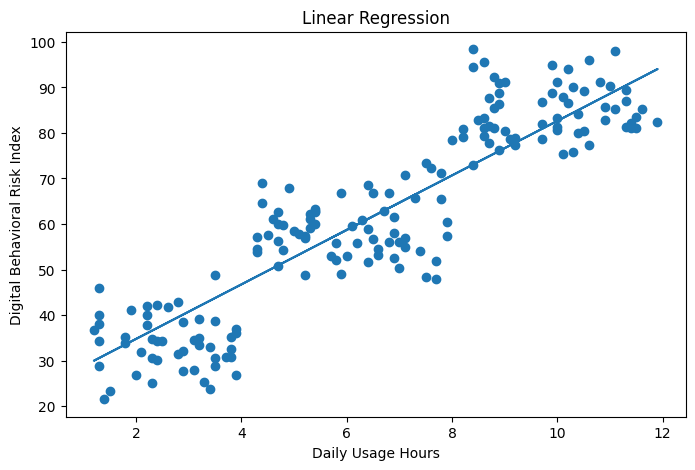

Linear Regression model saved as Pickle file
MAE : 4.504788195147884
MSE : 30.39842087225604
R2 Score : 0.9309935464497794
Intercept : 16.232345702651735
                      Feature  Coefficient
0           daily_usage_hours    -0.137934
1           night_usage_hours     0.142775
2      dopamine_trigger_score    -0.009504
3  emotional_dependency_score    -0.129072
4       behavioral_risk_score     0.772848


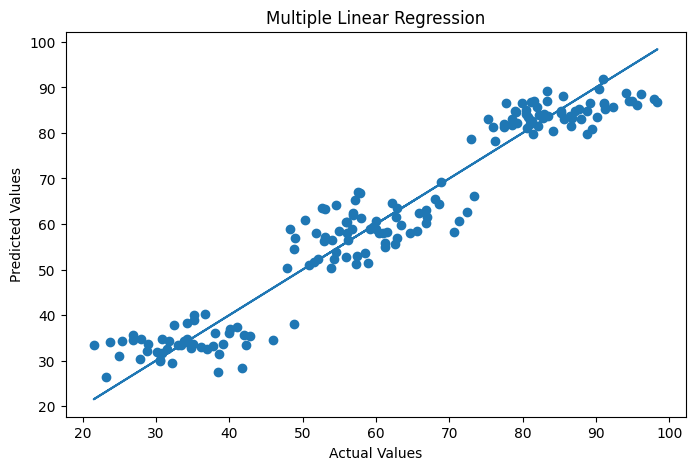

Multiple Linear Regression model saved as Joblib file


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import pandas as pd
import numpy as np

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

import pickle
import joblib


uploaded = files.upload()

df = pd.read_csv("digital_mirror_research_dataset_870_rows.csv")

print(df.head())


X = df[['daily_usage_hours']]

y = df['digital_behavioral_risk_index']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("R2 Score :", r2)

print("Intercept :", linear_model.intercept_)
print("Coefficient :", linear_model.coef_[0])

plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("Daily Usage Hours")
plt.ylabel("Digital Behavioral Risk Index")
plt.title("Linear Regression")

plt.show()

with open('linear_regression_model.pkl', 'wb') as file:
    pickle.dump(linear_model, file)

print("Linear Regression model saved as Pickle file")


X_multi = df[[
    'daily_usage_hours',
    'night_usage_hours',
    'dopamine_trigger_score',
    'emotional_dependency_score',
    'behavioral_risk_score'
]]

y_multi = df['digital_behavioral_risk_index']

X_train, X_test, y_train, y_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42
)

multi_model = LinearRegression()

multi_model.fit(X_train, y_train)

y_pred_multi = multi_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_multi)
mse = mean_squared_error(y_test, y_pred_multi)
r2 = r2_score(y_test, y_pred_multi)

print("MAE :", mae)
print("MSE :", mse)
print("R2 Score :", r2)

print("Intercept :", multi_model.intercept_)

coefficients = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': multi_model.coef_
})

print(coefficients)

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_multi)

plt.plot(y_test, y_test)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Linear Regression")

plt.show()

joblib.dump(multi_model, 'multiple_linear_regression_model.joblib')

print("Multiple Linear Regression model saved as Joblib file")

files.download('linear_regression_model.pkl')

files.download('multiple_linear_regression_model.joblib')

In [2]:
from google.colab import files

files.download('multiple_linear_regression_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

One Hot Encoding

Saving digital_mirror_research_dataset_870_rows.csv to digital_mirror_research_dataset_870_rows (1).csv
  participant_id  age  gender       occupation  daily_usage_hours  \
0          P0001   32   Other          Creator                2.4   
1          P0002   27   Other         Employee                3.9   
2          P0003   33  Female       Freelancer                3.7   
3          P0004   32    Male  College Student               10.1   
4          P0005   25   Other          Creator                1.8   

   night_usage_hours  app_switch_frequency  notification_check_frequency  \
0                1.1                    15                           102   
1                3.8                    20                            58   
2                0.2                    31                            68   
3                0.1                    16                           109   
4                1.0                    15                           141   

   short_video_consumpti

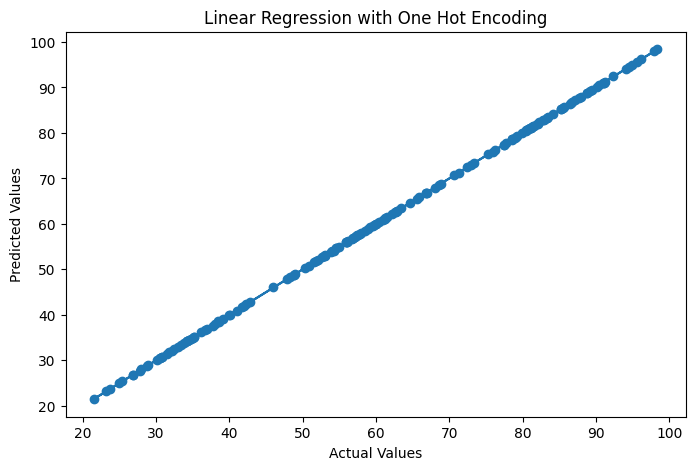

Linear Regression model saved as Pickle file
Linear Regression model saved as Joblib file


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import pandas as pd
import numpy as np

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

import pickle
import joblib


uploaded = files.upload()

df = pd.read_csv("digital_mirror_research_dataset_870_rows.csv")

print(df.head())

print(df.dtypes)

df_encoded = pd.get_dummies(df)

print(df_encoded.head())


X = df_encoded.drop('digital_behavioral_risk_index', axis=1)

y = df_encoded['digital_behavioral_risk_index']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("R2 Score :", r2)


print("Intercept :", linear_model.intercept_)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})

print(coefficients)


plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.plot(y_test, y_test)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression with One Hot Encoding")

plt.show()


with open('linear_regression_model.pkl', 'wb') as file:
    pickle.dump(linear_model, file)

print("Linear Regression model saved as Pickle file")


joblib.dump(linear_model, 'linear_regression_model.joblib')

print("Linear Regression model saved as Joblib file")


files.download('linear_regression_model.pkl')

files.download('linear_regression_model.joblib')

Train Test Split

In [4]:
import pandas as pd

from google.colab import files

from sklearn.model_selection import train_test_split


uploaded = files.upload()

df = pd.read_csv("digital_mirror_research_dataset_870_rows.csv")

print(df.head())


df_encoded = pd.get_dummies(df)


X = df_encoded.drop('digital_behavioral_risk_index', axis=1)

y = df_encoded['digital_behavioral_risk_index']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("X_train Shape :", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape :", y_test.shape)

Saving digital_mirror_research_dataset_870_rows.csv to digital_mirror_research_dataset_870_rows (2).csv
  participant_id  age  gender       occupation  daily_usage_hours  \
0          P0001   32   Other          Creator                2.4   
1          P0002   27   Other         Employee                3.9   
2          P0003   33  Female       Freelancer                3.7   
3          P0004   32    Male  College Student               10.1   
4          P0005   25   Other          Creator                1.8   

   night_usage_hours  app_switch_frequency  notification_check_frequency  \
0                1.1                    15                           102   
1                3.8                    20                            58   
2                0.2                    31                            68   
3                0.1                    16                           109   
4                1.0                    15                           141   

   short_video_consumpti

Logistic Regression

Saving digital_mirror_research_dataset_870_rows.csv to digital_mirror_research_dataset_870_rows (3).csv
  participant_id  age  gender       occupation  daily_usage_hours  \
0          P0001   32   Other          Creator                2.4   
1          P0002   27   Other         Employee                3.9   
2          P0003   33  Female       Freelancer                3.7   
3          P0004   32    Male  College Student               10.1   
4          P0005   25   Other          Creator                1.8   

   night_usage_hours  app_switch_frequency  notification_check_frequency  \
0                1.1                    15                           102   
1                3.8                    20                            58   
2                0.2                    31                            68   
3                0.1                    16                           109   
4                1.0                    15                           141   

   short_video_consumpti

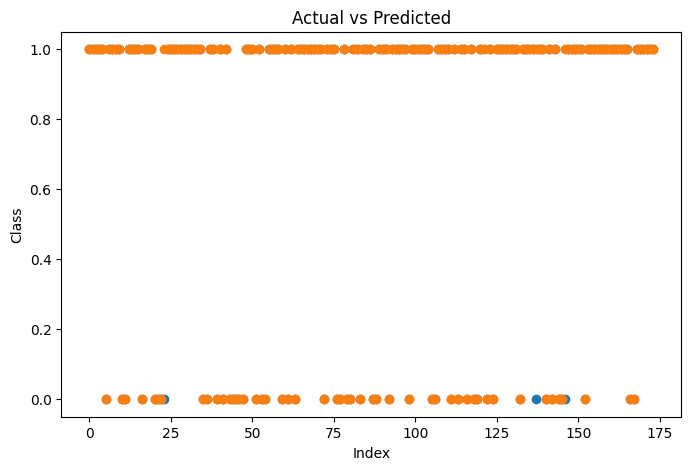

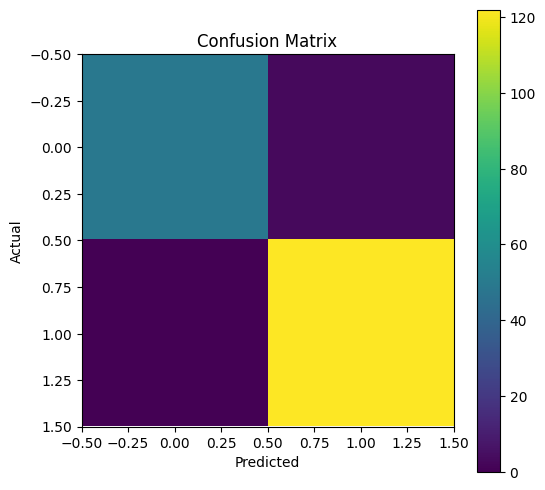

In [5]:
import pandas as pd
import numpy as np

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt


uploaded = files.upload()

df = pd.read_csv("digital_mirror_research_dataset_870_rows.csv")

print(df.head())

print(df.columns)


df_encoded = pd.get_dummies(df)


df_encoded['risk_category'] = np.where(
    df_encoded['digital_behavioral_risk_index'] > 50,
    1,
    0
)


X = df_encoded.drop(
    ['digital_behavioral_risk_index', 'risk_category'],
    axis=1
)

y = df_encoded['risk_category']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)


y_pred = logistic_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))


plt.figure(figsize=(8,5))

plt.scatter(range(len(y_test)), y_test)

plt.scatter(range(len(y_pred)), y_pred)

plt.xlabel("Index")
plt.ylabel("Class")

plt.title("Actual vs Predicted")

plt.show()


plt.figure(figsize=(6,6))

plt.imshow(confusion_matrix(y_test, y_pred))

plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()